# RAMIP data layer: GMST, GWL crossings, regional timeseries

One place that turns the raw RAMIP zarr archive into small, cached, analysis-ready tables:

1. **Annual GMST anomaly** (vs each model's own 1850–1900 `historical` baseline) for **every
   experiment and run** on disk — not just the ssp370 / ssp370-126aer pair — as a long-format CSV.
2. **GWL crossing years** (1.5, 2.0, 2.5, 3.0 K; first 10-yr running-mean window to reach the
   level, per run) as a tidy CSV, plus a per-model summary.
3. **AR6-land-region annual means** for `tas`, `tasmax`, `tasmin`, `pr`, every experiment and run,
   one netCDF per (variable, model).
4. A GMST trajectory overview figure across all experiments.

Baselines are reused from `aux/diagnostics/ramip_gwl/baseline_1850_1900.csv`
(computed in `ks_path_independence_ramip_gwl.ipynb`; CanESM5-1 borrows CanESM5).
Everything caches — reruns are cheap.

In [1]:
import os, re, glob, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import regionmask

import sys
sys.path.insert(0, '/burg-archive/home/mck2199/summer/bcd_me/code')
from funcs_support import get_params
dir_list = get_params()

warnings.filterwarnings('ignore', category=FutureWarning)

RAW    = dir_list['raw'] + 'ramip/'
MODELS = sorted(os.listdir(RAW))
VARS   = ['tas', 'tasmax', 'tasmin', 'pr']
GWLS   = [1.5, 2.0, 2.5, 3.0]
WIN    = 10                     # years, consistent with the GWL2.0 KS notebook
BASE   = (1850, 1900)

DL_DIR  = dir_list['aux'] + 'data_layer/'
REG_DIR = DL_DIR + 'regional/'
os.makedirs(REG_DIR, exist_ok=True)
out_dir = dir_list['aux'] + '../figures/'

BASE_FN = dir_list['aux'] + f'diagnostics/ramip_gwl/baseline_{BASE[0]}_{BASE[1]}.csv'
base_df = pd.read_csv(BASE_FN).set_index('model')


def member_files(mod, exp, var='tas'):
    """run -> file. Some runs exist at several time spans; keep the longest."""
    out = {}
    for f in sorted(glob.glob(f'{RAW}{mod}/{var}_Amon_{mod}_{exp}_r*.zarr')):
        run = re.search(r'_(r\d+i\d+p\d+f\d+)_', f).group(1)
        end = re.search(r'-(\d{4})\d{4}\.zarr$', f)
        end = int(end.group(1)) if end else 0
        if run not in out or end > out[run][1]:
            out[run] = (f, end)
    return {r: v[0] for r, v in out.items()}


def experiments(mod, var='tas'):
    """all experiment ids present for this model/variable"""
    pat = re.compile(rf'{var}_Amon_{re.escape(mod)}_(.+?)_r\d+i\d+p\d+f\d+_')
    return sorted({m.group(1) for f in glob.glob(f'{RAW}{mod}/{var}_Amon_{mod}_*.zarr')
                   if (m := pat.search(os.path.basename(f)))})


def gmst(da):
    return da.weighted(np.cos(np.deg2rad(da.lat))).mean([d for d in da.dims if d != 'time'])


for mod in MODELS:
    print(f'{mod:20s} exps: {experiments(mod)}')

/burg-archive/home/mck2199/summer/.venv312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CESM2                exps: ['ssp370-126aer', 'ssp370-AFR126aer', 'ssp370-EAS126aer', 'ssp370-LE', 'ssp370-NAE126aer', 'ssp370-SAS126aer']
CNRM-ESM2-1          exps: ['ssp370', 'ssp370-126aer', 'ssp370-AFR126aer', 'ssp370-ASIA126aer', 'ssp370-EAS126aer', 'ssp370-NAE126aer', 'ssp370-SAF126ca', 'ssp370-SAS126aer', 'ssp370-SAS126ca']
CanESM5-1            exps: ['ssp370', 'ssp370-126aer', 'ssp370-AFR126aer', 'ssp370-EAS126aer', 'ssp370-NAE126aer', 'ssp370-SAS126aer']
EC-Earth3-AerChem    exps: ['ssp370', 'ssp370-126aer', 'ssp370-AFR126aer', 'ssp370-EAS126aer', 'ssp370-NAE126aer', 'ssp370-SAS126aer']
GISS-E2-1-G          exps: ['ssp370', 'ssp370-126aer', 'ssp370-AFR126aer', 'ssp370-ASIA126aer', 'ssp370-EAS126aer', 'ssp370-NAE126aer', 'ssp370-SAF126ca', 'ssp370-SAS126aer', 'ssp370-SAS126ca']
MIROC6               exps: ['ssp370', 'ssp370-126aer', 'ssp370-AFR126aer', 'ssp370-ASIA126aer', 'ssp370-EAS126aer', 'ssp370-NAE126aer', 'ssp370-SAF126ca', 'ssp370-SAS126aer', 'ssp370-SAS126ca']
MRI-ESM2-0

## 1. Annual GMST anomaly, all experiments and runs

Long format: one row per (model, experiment, run, year). Anomaly is vs the model's own
1850–1900 baseline, so values are directly comparable across models and read as warming levels.

In [2]:
GMST_FN = DL_DIR + 'gmst_annual_long.csv'

if os.path.exists(GMST_FN):
    gm_df = pd.read_csv(GMST_FN)
    print(f'loaded cached GMST ({len(gm_df)} rows)')
else:
    rows = []
    for mod in MODELS:
        b = float(base_df.loc[mod, 'baseline_K'])
        for exp in experiments(mod):
            for run, fn in member_files(mod, exp).items():
                ds = xr.open_zarr(fn, consolidated=False)
                g = gmst(ds.tas).groupby('time.year').mean().compute() - b
                rows += [{'model': mod, 'exp': exp, 'run': run,
                          'year': int(y), 'gmst_anom': float(v)}
                         for y, v in zip(g.year.values, g.values)]
            print(f'  {mod} {exp}: {len(member_files(mod, exp))} runs', flush=True)
    gm_df = pd.DataFrame(rows)
    gm_df.to_csv(GMST_FN, index=False)
    print('saved', GMST_FN, len(gm_df), 'rows')

gm_df.groupby(['model', 'exp']).run.nunique().unstack(fill_value=0)

  CESM2 ssp370-126aer: 10 runs


  CESM2 ssp370-AFR126aer: 10 runs


  CESM2 ssp370-EAS126aer: 10 runs


  CESM2 ssp370-LE: 10 runs


  CESM2 ssp370-NAE126aer: 10 runs


...

  UKESM1-0-LL ssp370-EAS126aer: 10 runs


  UKESM1-0-LL ssp370-NAE126aer: 10 runs


  UKESM1-0-LL ssp370-SAS126aer: 9 runs


saved /burg-archive/home/mck2199/summer/summer_data/aux/data_layer/gmst_annual_long.csv 31787 rows


exp,ssp370,ssp370-126aer,ssp370-AFR126aer,ssp370-ASIA126aer,ssp370-EAS126aer,ssp370-LE,ssp370-NAE126aer,ssp370-SAF126ca,ssp370-SAS126aer,ssp370-SAS126ca,ssp370-ramip
model,,,,,,,,,,,
CESM2,0,10,10,0,10,10,10,0,10,0,0
CNRM-ESM2-1,10,10,10,10,10,0,10,10,10,10,0
CanESM5-1,10,10,10,0,10,0,10,0,10,0,0
EC-Earth3-AerChem,10,10,10,0,10,0,9,0,10,0,0
GISS-E2-1-G,10,10,10,10,10,0,10,9,10,9,0
MIROC6,10,10,10,6,10,0,10,1,10,2,0
MRI-ESM2-0,10,10,10,0,10,0,10,0,10,0,0
NorESM2-LM,7,10,9,0,9,0,10,0,9,0,2
UKESM1-0-LL,10,10,10,0,10,0,10,0,9,0,0


## 2. GWL crossing years

For each (model, experiment, run, GWL): last year of the first 10-yr window whose running-mean
GMST anomaly reaches the level. NaN = never reaches it within available data.

In [3]:
def gwl_window(series_years, series_vals, gwl, win=WIN):
    roll = pd.Series(series_vals, index=series_years).rolling(win).mean()
    hit = roll[roll >= gwl]
    return int(hit.index[0]) if len(hit) else np.nan


rows = []
for (mod, exp, run), s in gm_df.groupby(['model', 'exp', 'run']):
    s = s.sort_values('year')
    for gwl in GWLS:
        rows.append({'model': mod, 'exp': exp, 'run': run, 'gwl': gwl,
                     'window_end': gwl_window(s.year.values, s.gmst_anom.values, gwl),
                     'last_year': int(s.year.max())})
cross_df = pd.DataFrame(rows)
cross_df.to_csv(DL_DIR + 'gwl_crossings.csv', index=False)

# summary: median crossing year (and how many runs cross) per model x exp x gwl
summ = (cross_df.groupby(['model', 'exp', 'gwl'])
        .agg(n_runs=('run', 'nunique'),
             n_cross=('window_end', 'count'),
             median_end=('window_end', 'median')).reset_index())
summ.to_csv(DL_DIR + 'gwl_crossing_summary.csv', index=False)
print('saved gwl_crossings.csv +', DL_DIR + 'gwl_crossing_summary.csv')

# main-pair view at GWL2.0
main = summ[summ.exp.isin(['ssp370', 'ssp370-LE', 'ssp370-126aer']) & (summ.gwl == 2.0)]
main.pivot_table(index='model', columns='exp', values='median_end')

saved gwl_crossings.csv + /burg-archive/home/mck2199/summer/summer_data/aux/data_layer/gwl_crossing_summary.csv


exp,ssp370,ssp370-126aer,ssp370-LE
model,,,
CESM2,NaN,2037.0,2046.0
CNRM-ESM2-1,2055.0,2048.0,NaN
CanESM5-1,2027.0,2026.5,NaN
EC-Earth3-AerChem,2041.5,2034.5,NaN
GISS-E2-1-G,2040.0,2038.0,NaN
MIROC6,2068.0,2054.0,NaN
MRI-ESM2-0,2051.0,2042.5,NaN
NorESM2-LM,NaN,2055.5,NaN
UKESM1-0-LL,2038.0,2035.0,NaN


## 3. AR6-land-region annual means, all variables

46 AR6 land regions (regionmask) plus a `global-land` aggregate, area-weighted.
One netCDF per (variable, model): dims `(exp, run, year, region)` — ragged combinations padded
with NaN. Small files that every later phase (impacts, summary figures) reads instead of raw zarr.

In [4]:
ar6 = regionmask.defined_regions.ar6.land
land110 = regionmask.defined_regions.natural_earth_v5_0_0.land_110


def regional_annual(fn, var, mask3d, w):
    ds = xr.open_zarr(fn, consolidated=False)
    ann = ds[var].groupby('time.year').mean()
    return ann.weighted(mask3d * w).mean(('lat', 'lon')).compute()


for var in VARS:
    for mod in MODELS:
        out_fn = f'{REG_DIR}{var}_{mod}.nc'
        if os.path.exists(out_fn):
            print(f'{var} {mod}: cached')
            continue
        exps = experiments(mod, var)
        if not exps:
            print(f'{var} {mod}: no files')
            continue
        # masks once per model grid
        fn0 = next(iter(member_files(mod, exps[0], var).values()))
        grid = xr.open_zarr(fn0, consolidated=False)
        m3 = ar6.mask_3D(grid.lon, grid.lat)
        gl = (land110.mask_3D(grid.lon, grid.lat).isel(region=0)
              .expand_dims(region=1).assign_coords(region=[-1], names=('region', ['global-land']),
                                                   abbrevs=('region', ['GLB'])))
        mask3d = xr.concat([m3, gl], dim='region')
        w = np.cos(np.deg2rad(grid.lat))
        per_exp = []
        for exp in exps:
            per_run = []
            for run, fn in member_files(mod, exp, var).items():
                per_run.append(regional_annual(fn, var, mask3d, w).assign_coords(run=run))
            per_exp.append(xr.concat(per_run, dim='run').assign_coords(exp=exp))
            print(f'  {var} {mod} {exp}: {len(per_run)} runs', flush=True)
        da = xr.concat(per_exp, dim='exp', join='outer').rename(var)
        da.to_netcdf(out_fn)
        print(f'{var} {mod} -> {out_fn}')

  tas CESM2 ssp370-126aer: 10 runs


  tas CESM2 ssp370-AFR126aer: 10 runs


  tas CESM2 ssp370-EAS126aer: 10 runs


  tas CESM2 ssp370-LE: 10 runs


  tas CESM2 ssp370-NAE126aer: 10 runs


...

  pr UKESM1-0-LL ssp370-AFR126aer: 10 runs


  pr UKESM1-0-LL ssp370-EAS126aer: 10 runs


  pr UKESM1-0-LL ssp370-NAE126aer: 10 runs


  pr UKESM1-0-LL ssp370-SAS126aer: 9 runs


pr UKESM1-0-LL -> /burg-archive/home/mck2199/summer/summer_data/aux/data_layer/regional/pr_UKESM1-0-LL.nc


## 4. GMST trajectory overview

10-yr running-mean GMST anomaly, every experiment on disk, one panel per model.
The regional-cleanup arms sit between the two global arms; dashed lines mark the GWLs.

saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ramip_gmst_all_exps.png


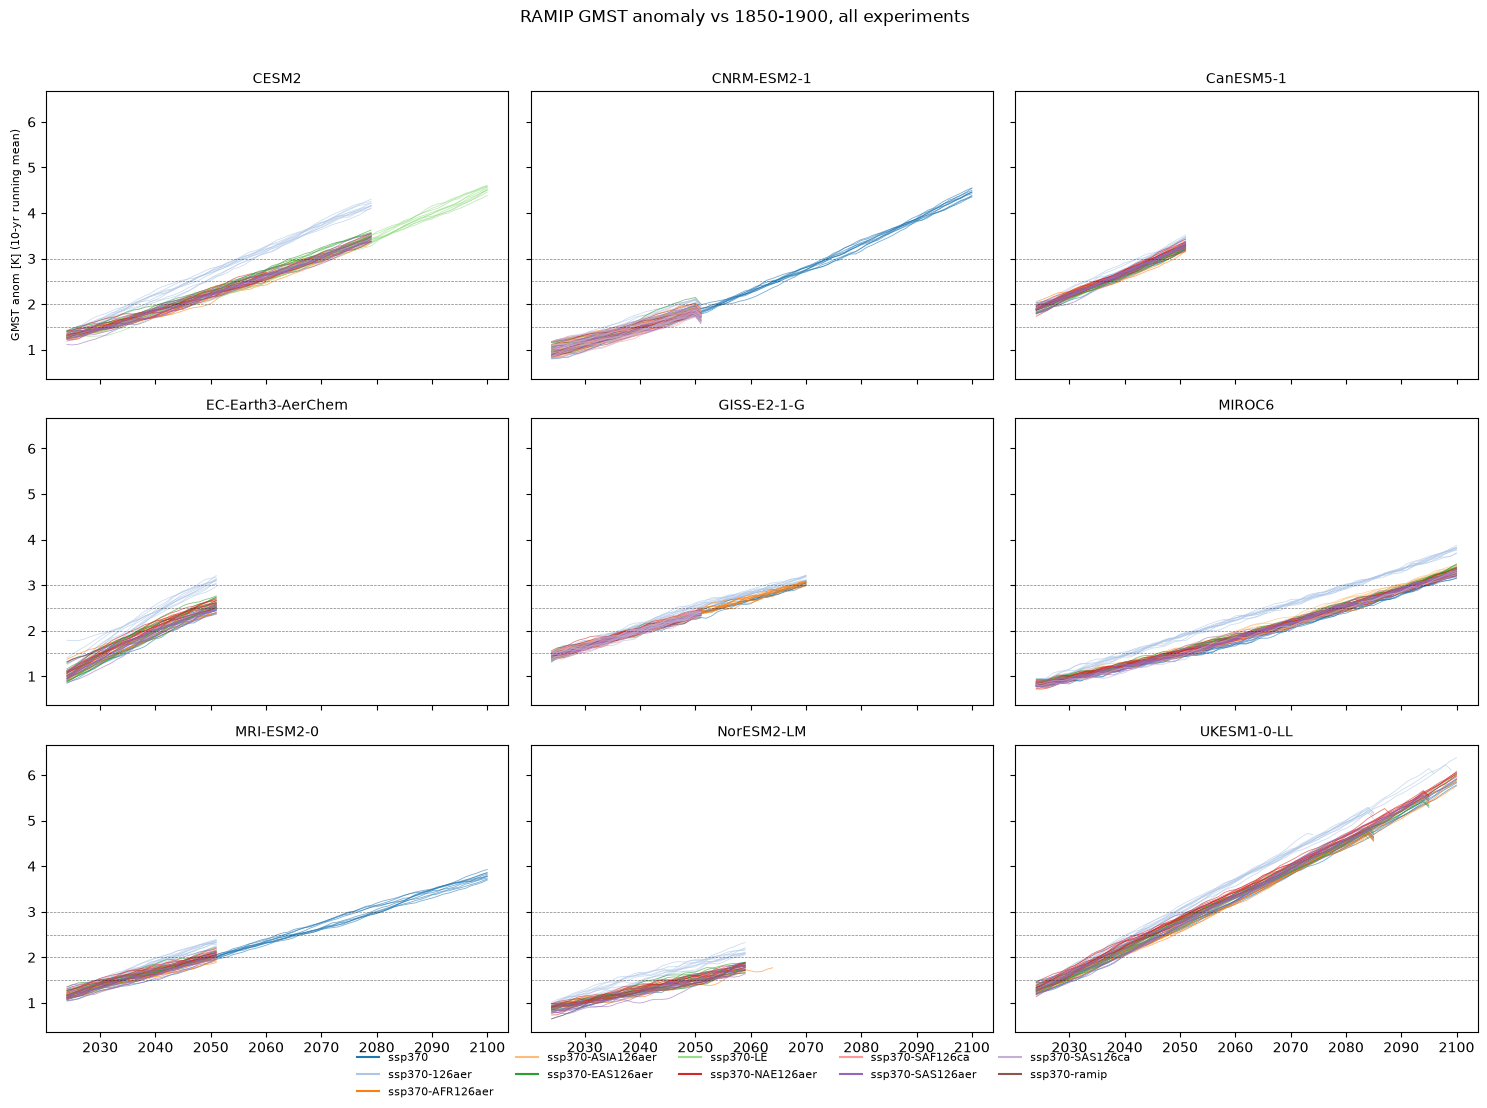

In [5]:
exps_all = sorted(gm_df.exp.unique())
col = {e: plt.cm.tab20(i / 20) for i, e in enumerate(exps_all)}

fig, axs = plt.subplots(3, 3, figsize=(15, 11), sharex=True, sharey=True)
for ax, mod in zip(axs.flat, MODELS):
    sub = gm_df[gm_df.model == mod]
    for exp, se in sub.groupby('exp'):
        piv = se.pivot_table(index='year', columns='run', values='gmst_anom')
        ax.plot(piv.index, piv.rolling(WIN).mean().values, color=col[exp], lw=0.6, alpha=0.6)
    for gwl in GWLS:
        ax.axhline(gwl, color='k', ls='--', lw=0.5, alpha=0.5)
    ax.set_title(mod, fontsize=10)
axs[0, 0].set_ylabel('GMST anom [K] (10-yr running mean)', fontsize=8)
handles = [plt.Line2D([], [], color=col[e], label=e) for e in exps_all]
fig.legend(handles=handles, ncol=5, loc='lower center', fontsize=8, frameon=False)
fig.suptitle(f'RAMIP GMST anomaly vs {BASE[0]}-{BASE[1]}, all experiments', y=0.995)
fig.tight_layout(rect=[0, 0.03, 1, 0.98])
fig.savefig(out_dir + 'ramip_gmst_all_exps.png', dpi=150, bbox_inches='tight')
print('saved', out_dir + 'ramip_gmst_all_exps.png')